In [1]:
import torch
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

# ==================== SETUP INICIAL ====================
# Detecta GPU disponível (mais rápido) ou usa CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Precision: bfloat16 é mais rápido em GPU modernas (Ampere+), float32 é universal
dtype = torch.bfloat16 if (device.type == "cuda" and torch.cuda.is_bf16_supported()) else torch.float32
print(f"Device: {device} | Precision: {dtype}")

# Seed para resultados reproduzíveis
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# Carrega dados brutos
dados = pd.read_csv("../data/raw/BTCUSDT_5m.txt", delimiter=";")

print(f"Dados carregados: {len(dados)} registros")

Device: cpu | Precision: torch.float32
Dados carregados: 735265 registros


In [2]:
# ==================== CONFIGURAÇÕES PRÉ-TREINAMENTO ====================
TIMESTAMP_COLUMN = 'timestamp'  # Coluna com timestamps
TARGET_COLUMN = ['Vol']     # Coluna a prever (volatilidade)
ID_COLUMNS = []             # Sem IDs (série única)

# Tamanhos das janelas: histórico 7 dias, previsão 1 dia (dados diários)
CONTEXT_LENGTH = 512         # Janela histórica: x dias passados
FORECAST_HORIZON = 96        # Prever: x dias à frente

# Divisão treino/validação/teste
TRAIN_FRAC, VALID_FRAC = 0.7, 0.1  # 70% treino, 10% validação, 20% teste

# Hyperparâmetros do modelo
PATCH_LENGTH = 1            # Tamanho do patch (1=sem patchificação, mantém cada dia)
BATCH_SIZE = 32             # Samples por batch (reduzir se GPU memory limitada)
NUM_WORKERS = 4             # Workers para data loading (0 em Windows)
EPOCHS = 30                 # Reduzido: 50→30 (volatilidade tem ciclos curtos)
LEARNING_RATE = 1e-3        # Taxa de aprendizado

In [3]:
dados[TIMESTAMP_COLUMN] = pd.to_datetime(dados[TIMESTAMP_COLUMN], unit='ms', errors='raise')
dados = dados.sort_values(TIMESTAMP_COLUMN).reset_index(drop=True)

In [9]:
print("Calculando features de volatilidade")
    
# Calcula retornos logarítmicos
dados['log_returns'] = np.log(dados['close'] / dados['close'].shift(1))
dados['squared_log_returns'] = dados['log_returns'] ** 2

# Agrupa por dia
dados_indexed = dados.set_index(TIMESTAMP_COLUMN)
daily_realized_variance = dados_indexed.groupby(dados_indexed.index.date)['squared_log_returns'].sum()
# daily_realized_variance = dados_indexed.groupby(dados_indexed.index.date)['log_returns'].sum()

# Cria features de volatilidade
dados_vol = pd.DataFrame({'Vol': daily_realized_variance})
dados_vol.reset_index(names=TIMESTAMP_COLUMN, inplace=True)

Calculando features de volatilidade


KeyError: 'close'

In [ ]:
dados = dados_vol[[TIMESTAMP_COLUMN] + TARGET_COLUMN]

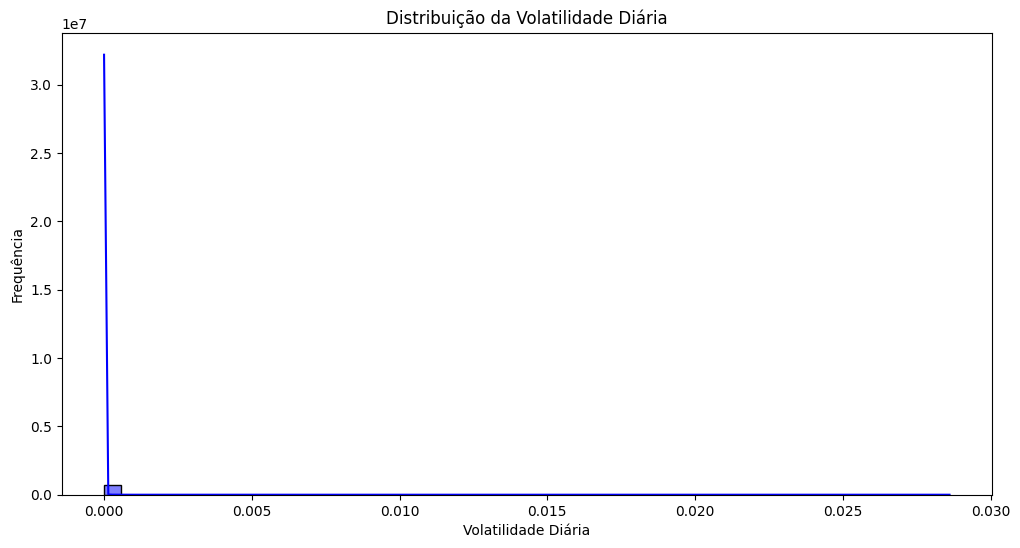

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

sns.histplot(dados['Vol'], bins=50, kde=True, color='blue')
plt.title('Distribuição da Volatilidade Diária')

plt.xlabel('Volatilidade Diária')
plt.ylabel('Frequência')

plt.show()

In [11]:
from tsfm_public.toolkit.util import select_by_index

n = len(dados)
train_end = int(n * TRAIN_FRAC)
valid_end = int(n * (TRAIN_FRAC + VALID_FRAC))

train_df = select_by_index(dados, start_index=None, end_index=train_end)
valid_df = select_by_index(dados, start_index=train_end - CONTEXT_LENGTH, end_index=valid_end)
test_df = select_by_index(dados, start_index=valid_end - CONTEXT_LENGTH, end_index=None)

In [357]:
# ==================== PRÉ-PROCESSAMENTO: NORMALIZAÇÃO ====================
from tsfm_public.toolkit.time_series_preprocessor import TimeSeriesPreprocessor
from tsfm_public.toolkit.dataset import ForecastDFDataset

# Normaliza dados: subtrai média, divide por std
# Essencial para modelos deep learning (converge melhor)
tsp = TimeSeriesPreprocessor(
    timestamp_column=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    id_columns=ID_COLUMNS,
    scaling='std'  # standardscaler: (x - mean)/std
)
tsp.train(train_df)  # Aprende mean/std no treino

def make_ds(df):
    """Cria dataset com janelas deslizantes"""
    return ForecastDFDataset(
        tsp.preprocess(df),  # Normaliza usando parâmetros do treino
        id_columns=ID_COLUMNS,
        target_columns=TARGET_COLUMN,
        context_length=CONTEXT_LENGTH,      # Quantos dias de histórico usar
        prediction_length=FORECAST_HORIZON, # Quantos dias prever
    )

train_ds, valid_ds, test_ds = map(make_ds, [train_df, valid_df, test_df])
print(f"Treino: {len(train_ds)} amostras | Val: {len(valid_ds)} | Teste: {len(test_ds)}")

Treino: 514078 amostras | Val: 73432 | Teste: 146958


In [ ]:
train_ds

In [358]:
train_vw = train_ds.datasets[0].data_df

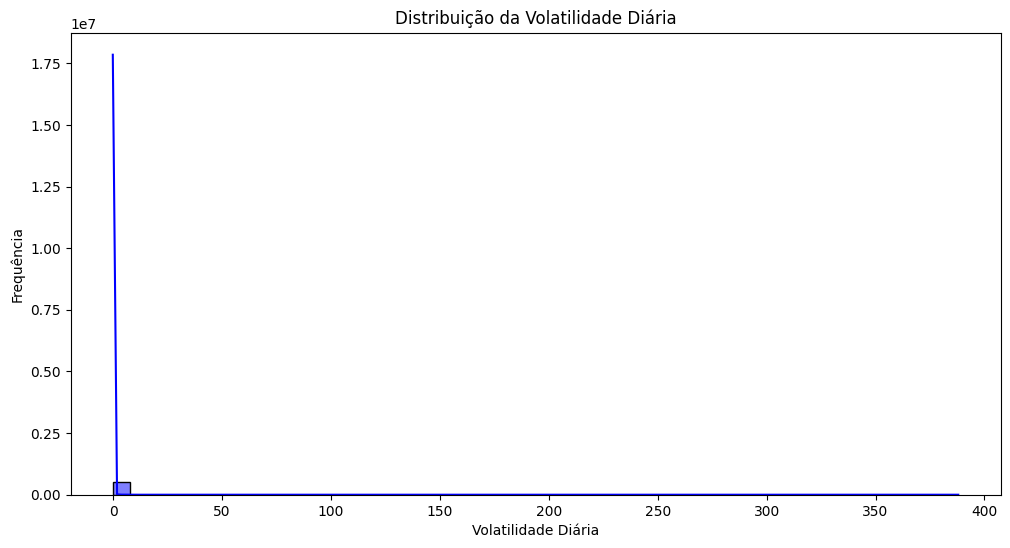

In [359]:
plt.figure(figsize=(12, 6))

sns.histplot(train_vw['Vol'], bins=50, kde=True, color='blue')
plt.title('Distribuição da Volatilidade Diária')

plt.xlabel('Volatilidade Diária')
plt.ylabel('Frequência')

plt.show()

In [360]:
# ==================== MÉTRICAS DE AVALIAÇÃO ====================
from sklearn.metrics import mean_squared_error, mean_absolute_error

def compute_metrics(eval_pred):
    """Calcula MAE, MSE, RMSE, MAPE denormalizando as previsões"""
    pred, labels = eval_pred
    pred = pred[0] if isinstance(pred, tuple) else pred
    C = len(TARGET_COLUMN)

    # Recupera scaler original (inverte normalização)
    scaler = next(iter(tsp.target_scaler_dict.values()))
    pred = scaler.inverse_transform(pred.reshape(-1, C)).reshape(pred.shape)
    labels = scaler.inverse_transform(labels.reshape(-1, C)).reshape(labels.shape)

    # Achata arrays para cálculo de métricas
    pred = pred.reshape(-1)
    labels = labels.reshape(-1)

    mae = mean_absolute_error(labels, pred)
    mse = mean_squared_error(labels, pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((labels - pred) / (np.abs(labels) + 1e-9))) * 100
    
    return {'MSE': mse, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

In [ ]:
# ==================== FUNÇÃO: AVALIAR E VISUALIZAR ====================
from transformers import Trainer, TrainingArguments

def evaluate_and_visualize(model, test_dataset, tsp, model_name="Modelo"):
    """Avalia modelo no conjunto de teste e plota resultados"""
    
    trainer = Trainer(
        model=model,
        args=TrainingArguments(
            output_dir="metric_temp",
            label_names=["future_values"]
        )
    )

    # Predições
    outputs = trainer.predict(test_dataset)
    predictions = outputs.predictions[0] if isinstance(outputs.predictions, tuple) else outputs.predictions
    labels = outputs.label_ids

    C = len(TARGET_COLUMN)
    scaler = next(iter(tsp.target_scaler_dict.values()))
    
    # Desnormaliza
    pred_original = scaler.inverse_transform(predictions.reshape(-1, C)).reshape(predictions.shape)
    labels_original = scaler.inverse_transform(labels.reshape(-1, C)).reshape(labels.shape)

    pred_flat = pred_original.reshape(-1)
    labels_flat = labels_original.reshape(-1)

    # Calcula métricas
    metrics = {
        'MSE': mean_squared_error(labels_flat, pred_flat),
        'MAE': mean_absolute_error(labels_flat, pred_flat),
        'RMSE': np.sqrt(mean_squared_error(labels_flat, pred_flat)),
        'MAPE': np.mean(np.abs((labels_flat - pred_flat) / (np.abs(labels_flat) + 1e-9))) * 100
    }

    print(f"\n=== AVALIAÇÃO {model_name} ===")
    for metric_name, metric_value in metrics.items():
        print(f"  {metric_name}: {metric_value:.6e}")

    print(f"Shape predictions: {pred_original.shape}, labels: {labels_original.shape}")

    # ===== 1. SÉRIE TEMPORAL COMPLETA =====
    plt.figure(figsize=(16, 6))
    
    pred_series = pred_flat
    labels_series = labels_flat
    
    x_axis = np.arange(len(labels_series))
    
    plt.plot(x_axis, labels_series, 'b-', linewidth=1.5, label='Valor Real', alpha=0.9)
    plt.plot(x_axis, pred_series, 'r-', linewidth=2.5, label='Predição', alpha=0.7)
    
    plt.xlabel('Tempo (samples)', fontsize=12)
    plt.ylabel('Log-Volatilidade', fontsize=12)
    plt.title(f'{model_name} - Série Temporal Completa (Teste)', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===== 2. ZOOM: Primeiros 500 samples =====
    zoom_size = min(500, len(labels_series))
    plt.figure(figsize=(16, 6))
    
    x_zoom = np.arange(zoom_size)
    
    plt.plot(x_zoom, labels_series[:zoom_size], 'b-', linewidth=2, label='Valor Real', marker='o', markersize=3, alpha=0.9)
    plt.plot(x_zoom, pred_series[:zoom_size], 'r-', linewidth=2.5, label='Predição', marker='s', markersize=3, alpha=0.7)
    
    plt.xlabel('Tempo (samples)', fontsize=12)
    plt.ylabel('Log-Volatilidade', fontsize=12)
    plt.title(f'{model_name} - Detalhe dos Primeiros {zoom_size} Samples', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11, loc='best')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # ===== 3. SCATTER: Valor Previsto vs Real =====
    plt.figure(figsize=(10, 10))
    
    # Amostra 5000 pontos para não ficar muito denso
    sample_indices = np.random.choice(len(pred_series), min(5000, len(pred_series)), replace=False)
    
    plt.scatter(labels_series[sample_indices], pred_series[sample_indices], alpha=0.5, s=20, edgecolors='none')
    
    # Linha de perfeição (y=x)
    min_val = min(labels_series.min(), pred_series.min())
    max_val = max(labels_series.max(), pred_series.max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Previsão Perfeita')
    
    plt.xlabel('Valor Real', fontsize=12)
    plt.ylabel('Valor Previsto', fontsize=12)
    plt.title(f'{model_name} - Valor Previsto vs Real', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

    # ===== 4. ERRO DE PREVISÃO =====
    plt.figure(figsize=(16, 4))
    erro = labels_series - pred_series
    
    plt.plot(x_axis, erro, 'purple', linewidth=1, alpha=0.7)
    plt.axhline(y=0, color='k', linestyle='--', linewidth=1, alpha=0.5)
    plt.fill_between(x_axis, erro, 0, alpha=0.3, color='purple')
    
    plt.xlabel('Tempo (samples)', fontsize=12)
    plt.ylabel('Erro (Real - Predição)', fontsize=12)
    plt.title(f'{model_name} - Erro de Previsão', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    metrics["predictions"] = pred_original
    metrics["labels"] = labels_original
    return metrics

# ZERO-SHOT: Modelo Pré-Treinado

In [383]:
# ==================== CARREGAR MODELO PRÉ-TREINADO ====================
from transformers import PatchTSTConfig, PatchTSTForPrediction

BASE_MODEL = "ibm-granite/granite-timeseries-patchtst"

# Configuração: adapta modelo genérico para seu dataset
config = PatchTSTConfig.from_pretrained(BASE_MODEL)
config.num_input_channels = len(TARGET_COLUMN)  # 1 feature (Vol)

# Carrega weights pré-treinados
model = PatchTSTForPrediction.from_pretrained(
    BASE_MODEL,
    config=config
).to(device).to(dtype)

print(f"Modelo carregado: {BASE_MODEL}")
print(f"Num parâmetros: {model.num_parameters():,}")

Modelo carregado: ibm-granite/granite-timeseries-patchtst
Num parâmetros: 614,496


Avaliando modelo zero-shot (pré-treinado)...



=== AVALIAÇÃO Pré-Treinado (Zero-Shot) ===
  MSE: 1.056924e-09
  MAE: 5.812964e-06
  RMSE: 3.251037e-05
  MAPE: 2.001597e+04
Shape predictions: (146958, 96, 1), labels: (146958, 96, 1)


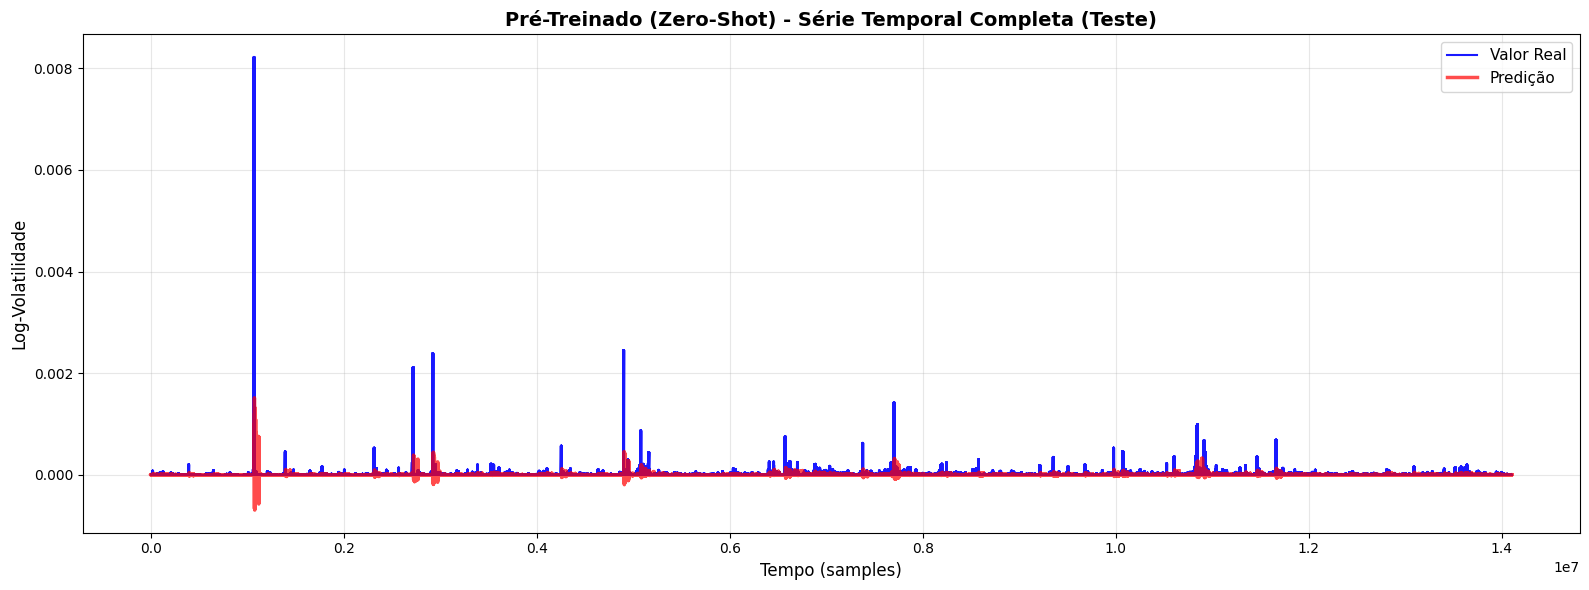

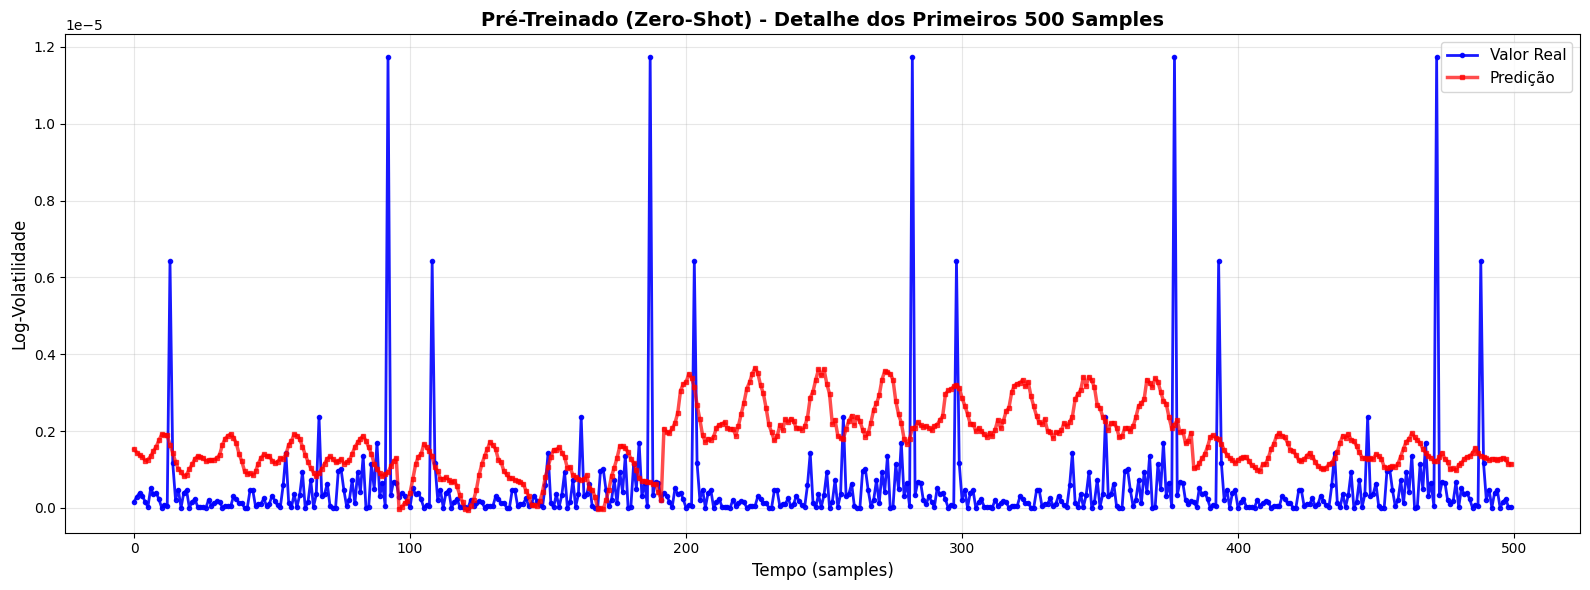

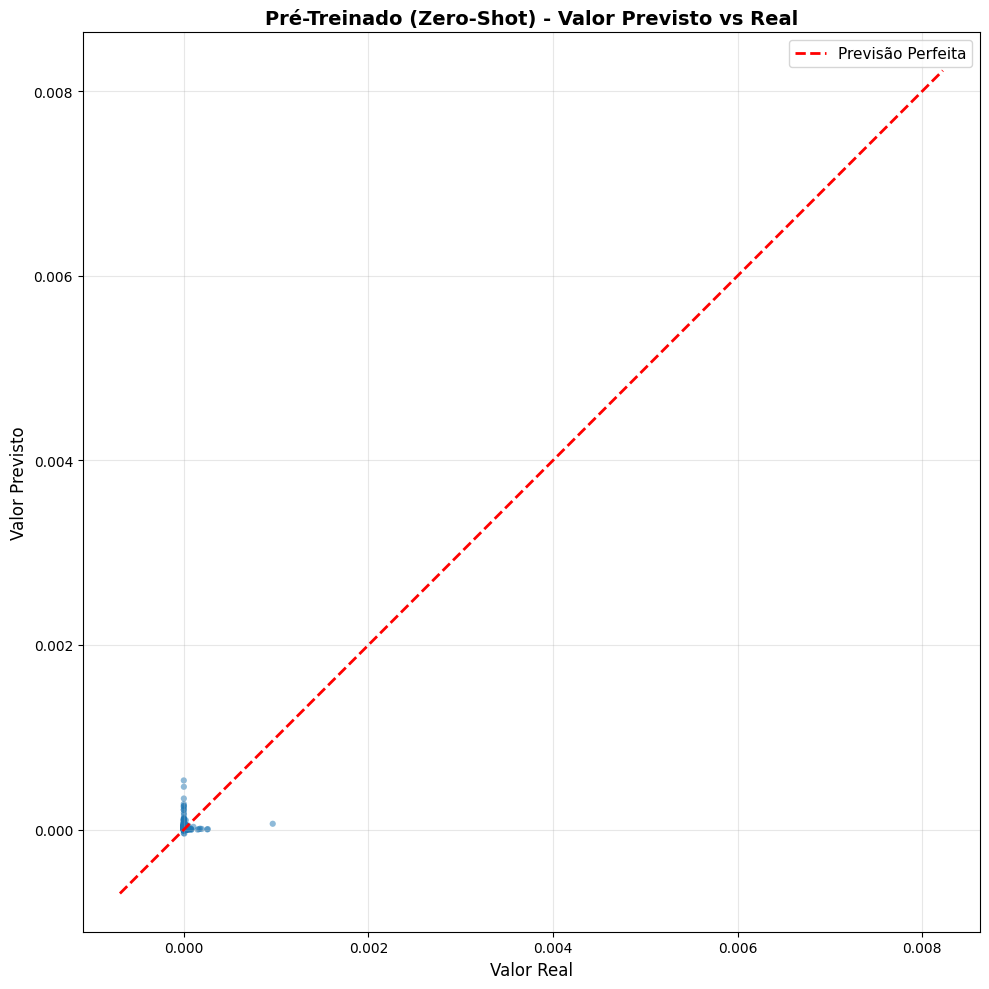

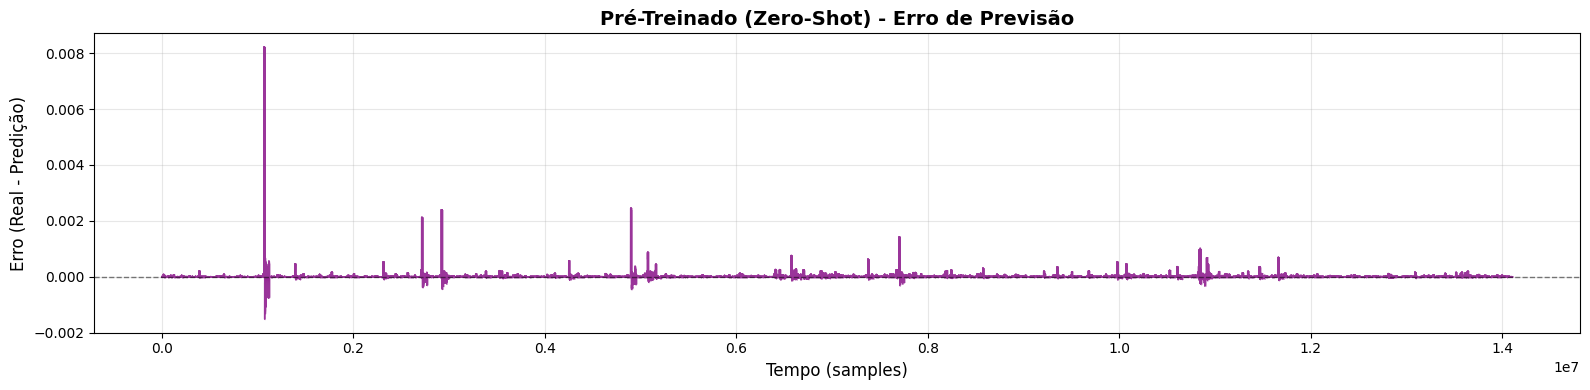

In [384]:
# ==================== EVALUA MODELO PRÉ-TREINADO ====================
print("Avaliando modelo zero-shot (pré-treinado)...")
results_pretrained = evaluate_and_visualize(model, test_ds, tsp, "Pré-Treinado (Zero-Shot)")

# FINE-TUNING: Adaptar Modelo ao seu Contexto

In [364]:
# ==================== RECRIAR DATASETS PARA FINE-TUNING ====================
# Usa mesma config de treino/val/teste
CONTEXT_LENGTH = 7
FORECAST_HORIZON = 1

tsp_finetune = TimeSeriesPreprocessor(
    timestamp_column=TIMESTAMP_COLUMN,
    target_column=TARGET_COLUMN,
    id_columns=ID_COLUMNS,
    scaling='std'
)
tsp_finetune.train(train_df)

def make_ds_ft(df):
    return ForecastDFDataset(
        tsp_finetune.preprocess(df),
        id_columns=ID_COLUMNS,
        target_columns=TARGET_COLUMN,
        context_length=CONTEXT_LENGTH,
        prediction_length=FORECAST_HORIZON,
    )

train_ds_ft, valid_ds_ft, test_ds_ft = map(make_ds_ft, [train_df, valid_df, test_df])
print(f"Datasets fine-tune: Train={len(train_ds_ft)}, Valid={len(valid_ds_ft)}, Test={len(test_ds_ft)}")

Datasets fine-tune: Train=514678, Valid=74032, Test=147558


In [365]:
# ==================== CONFIGURAÇÃO DO MODELO PARA FINE-TUNING ====================
from transformers import (
    EarlyStoppingCallback,
    PatchTSTConfig,
    PatchTSTForPrediction,
    Trainer,
    TrainingArguments    
)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
dtype = torch.bfloat16 if device.type == "cuda" else torch.float32
print(f"Device: {device} | Dtype: {dtype}")

# Configuração: hiperparâmetros do Transformer
config = PatchTSTConfig.from_pretrained(
    BASE_MODEL,
    context_length=CONTEXT_LENGTH,           # 7 dias de histórico
    patch_length=PATCH_LENGTH,               # 1 (cada dia = 1 patch)
    num_input_channels=len(TARGET_COLUMN),   # 1 feature (Vol)
    patch_stride=PATCH_LENGTH,               # Stride = patch_length (sem sobreposição)
    prediction_length=FORECAST_HORIZON,      # Prever 1 dia
    # === Arquitetura Transformer ===
    d_model=64,              # Dimensão interna (64→32 p/ dados pequenos) [Original: 128]
    num_attention_heads=4,   # Cabeças atenção (2 se d_model=32) [Original: 16]
    num_hidden_layers=2,     # Profundidade (reduzido para evitar overfitting) [Original: 3]
    ffn_dim=256,             # Feedforward dim (reduzido) [Original: 512]
    # === Regularização ===
    dropout=0.15,            # Dropout (reduzido) [Original: 0.2]
    head_dropout=0.15,       # Dropout nas cabeças [Original: 0.2]
    # === Outras configs ===
    scaling='std',           # Normalização: std = (x-mean)/std
    loss='mse',              # Loss function: Mean Squared Error
    pre_norm=True,           # Layer norm antes da atenção (mais estável)
    norm_type='batchnorm',   # Batch normalization
)

model_ft = PatchTSTForPrediction(config=config).to(device).to(dtype)
print(f"Modelo criado: {model_ft.num_parameters():,} parâmetros")

Device: cpu | Dtype: torch.float32
Modelo criado: 100,737 parâmetros
Modelo criado: 100,737 parâmetros


In [366]:
# ==================== TREINAMENTO ====================
train_args = TrainingArguments(
    output_dir="../models",
    overwrite_output_dir=True,
    learning_rate=LEARNING_RATE,              # 1e-3: ajuste fino típico
    num_train_epochs=EPOCHS,                  # 30 épocas (volatilidade converge rápido)
    do_eval=True,
    eval_strategy="epoch",                    # Valida a cada época
    per_device_train_batch_size=BATCH_SIZE,   # 32 (reduzir se mem limitada)
    per_device_eval_batch_size=BATCH_SIZE,
    dataloader_num_workers=NUM_WORKERS,       # 0 em Windows
    save_strategy="epoch",                    # Salva checkpoint cada época
    logging_strategy="epoch",                 # Log cada época
    save_total_limit=1,                       # Mantém apenas melhor modelo
    fp16=(dtype == torch.float16),
    bf16=(dtype == torch.bfloat16),           # Precisão reduzida (mais rápido)
    logging_dir="../logs",
    load_best_model_at_end=True,              # Carrega melhor modelo ao final
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    label_names=["future_values"],
)

# Early stopping: se validação não melhorar em 5 épocas, para
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,
    early_stopping_threshold=0.0
)

trainer = Trainer(
    model=model_ft,
    args=train_args,
    train_dataset=train_ds_ft,
    eval_dataset=valid_ds_ft,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

print("Iniciando fine-tuning...")
trainer.train()

Iniciando fine-tuning...


Epoch,Training Loss,Validation Loss,Mse,Mae,Rmse,Mape
1,0.892100,0.047494,0.000000,0.000002,0.000016,2908.961678
2,0.903400,0.047585,0.000000,0.000002,0.000016,3013.661575
3,0.876700,0.047437,0.000000,0.000002,0.000016,2603.611946
4,0.879100,0.048939,0.000000,0.000002,0.000016,1940.734100
5,0.869400,0.047391,0.000000,0.000002,0.000016,2741.954041
6,0.866200,0.047454,0.000000,0.000002,0.000016,2398.875046
7,0.871400,0.047516,0.000000,0.000002,0.000016,2373.301315
8,0.870000,0.047589,0.000000,0.000002,0.000016,2227.583885
9,0.872500,0.047407,0.000000,0.000002,0.000016,2542.825699
10,0.870700,0.047387,0.000000,0.000002,0.000016,2483.711433


TrainOutput(global_step=241260, training_loss=0.8754434077862058, metrics={'train_runtime': 5318.9479, 'train_samples_per_second': 2902.894, 'train_steps_per_second': 90.717, 'total_flos': 32663684142180.0, 'train_loss': 0.8754434077862058, 'epoch': 15.0})

In [367]:
output.predictions[0].shape

(833, 24, 1)

In [368]:
from pathlib import Path
save_dir = Path("../models")
model_ft.save_pretrained(save_dir)
print(f"Model saved to {save_dir}")

Model saved to ..\models


Avaliando modelo fine-tuned...



=== AVALIAÇÃO Fine-Tuned ===
  MSE: 6.930992e-10
  MAE: 2.196037e-06
  RMSE: 2.632678e-05
  MAPE: 2.763390e+03
Shape predictions: (147558, 1, 1), labels: (147558, 1, 1)


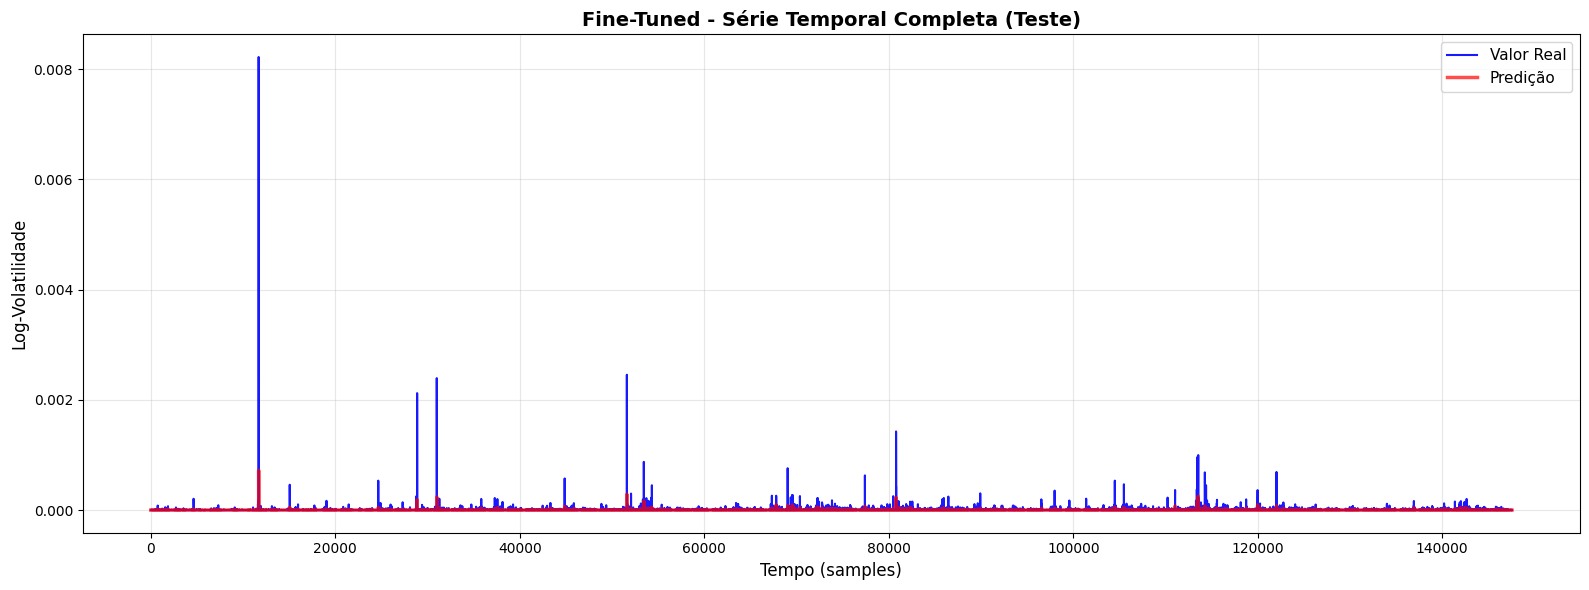

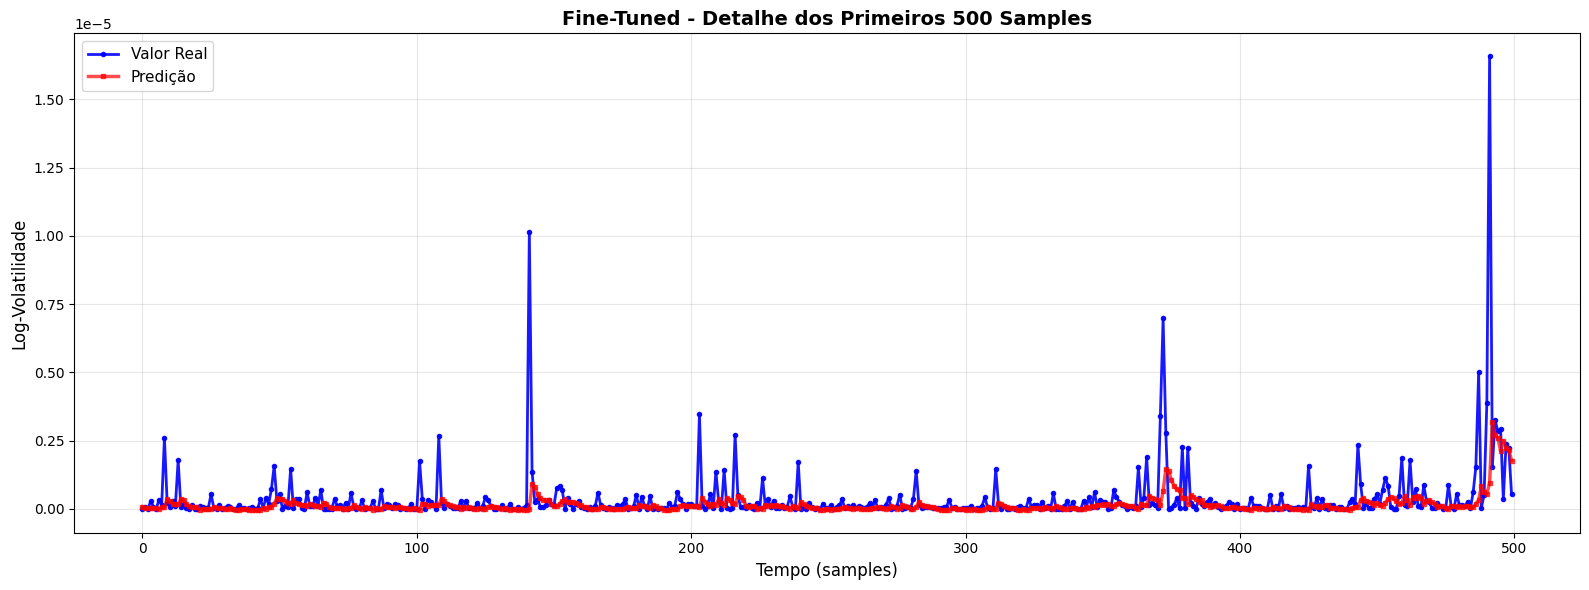

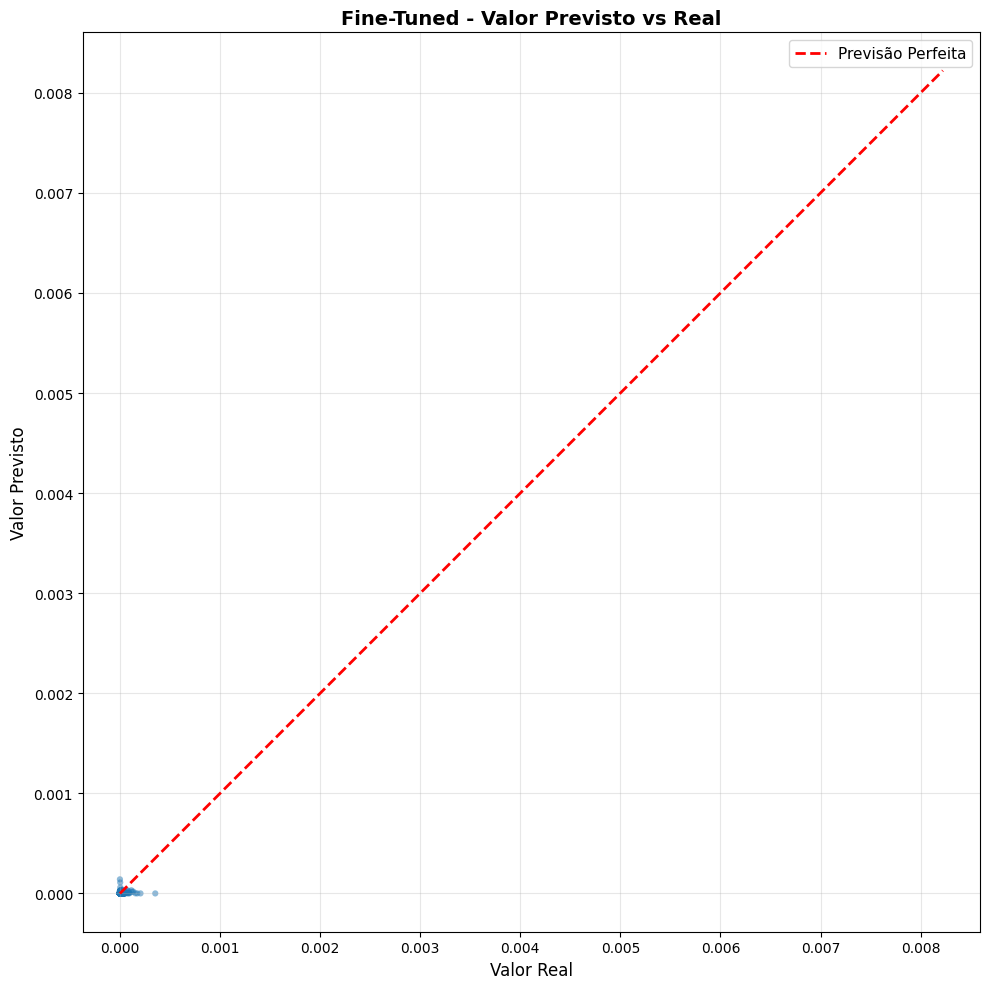

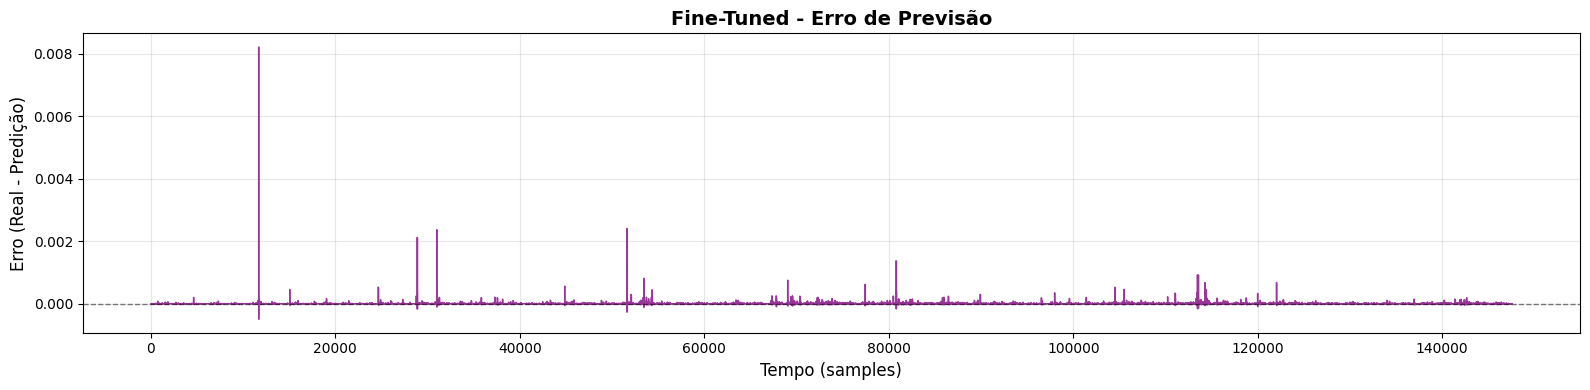

In [382]:
# ==================== AVALIAR MODELO TREINADO ====================
print("Avaliando modelo fine-tuned...")
results_finetuned = evaluate_and_visualize(model_ft, test_ds_ft, tsp_finetune, "Fine-Tuned")

Pré-treinado: alinhado (146958, 2)
Fine-tuned: alinhado (147558, 2)

Combined shape: (147558, 3)

Combined shape: (147558, 3)


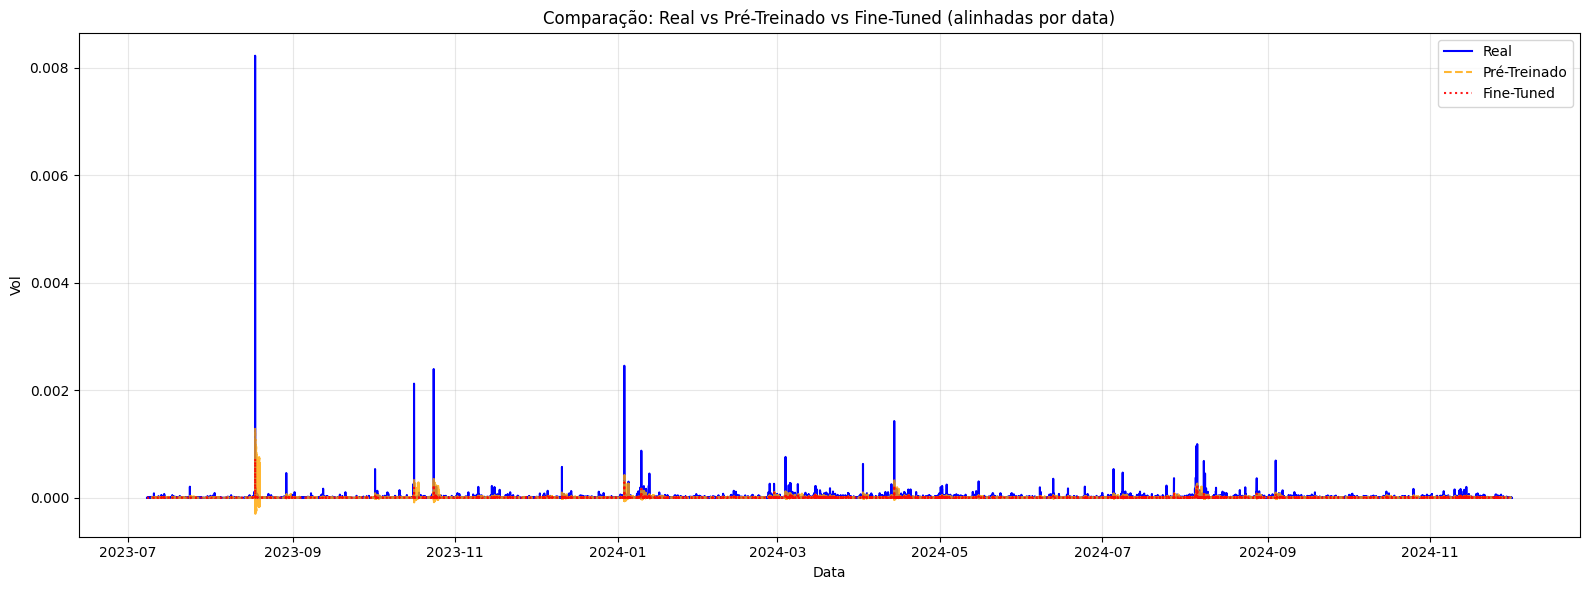

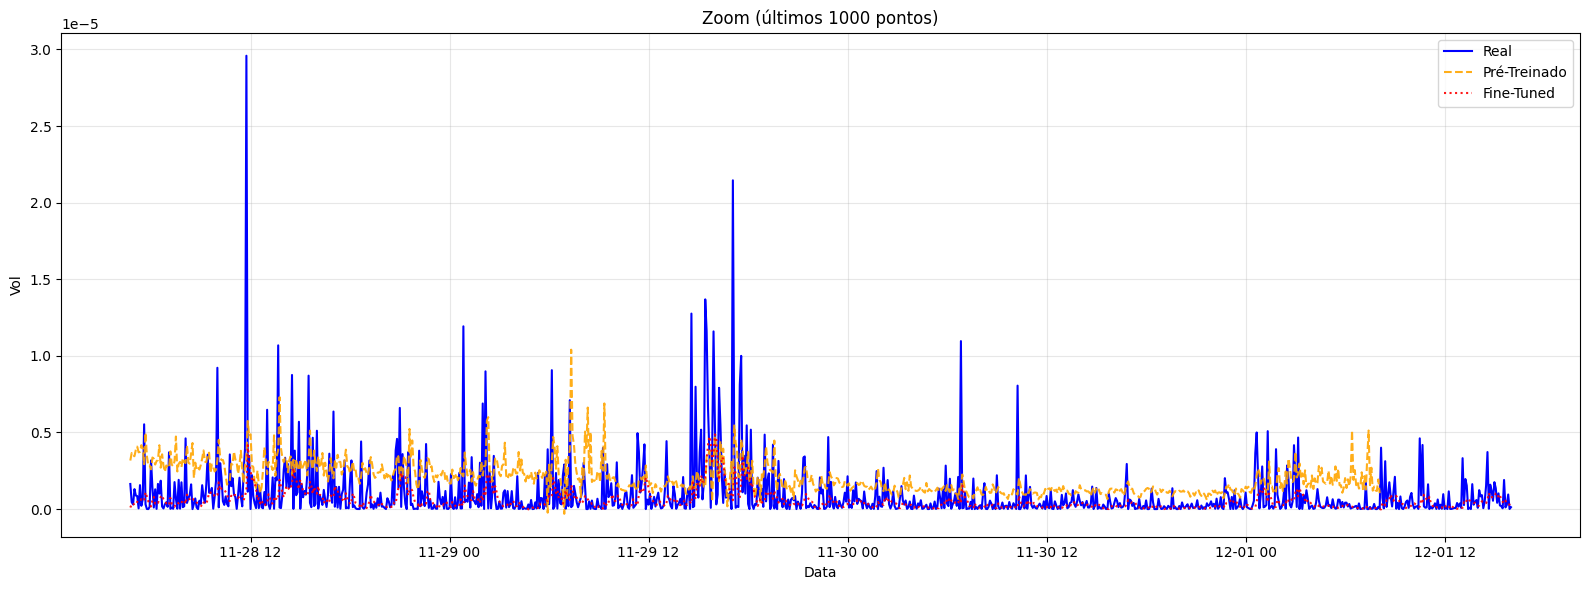


Métricas comparativas:
  pretrained_MSE: 1.298531e-09
  pretrained_MAE: 6.784081e-06
  finetuned_MSE: 6.930992e-10
  finetuned_MAE: 2.196036e-06

Arquivo salvo: ../output/combined_predictions_aligned.csv

Arquivo salvo: ../output/combined_predictions_aligned.csv


In [385]:
# ==================== ALINHAR PREVISÕES COM DATAS E PLOTAR ====================
# Gera séries temporais com (timestamp -> previsão, real) para cada modelo

def align_preds_to_dates(preds, labels, original_df, tsp_local, context_length, prediction_length, timestamp_col=TIMESTAMP_COLUMN):
    """Alinha um array de previsões/labels (num_samples, horizon, channels)
    às datas alvo extraídas do DataFrame original (antes da criação de janelas).

    Retorna um DataFrame indexado por timestamp com colunas ['pred','label']
    usando o primeiro passo do horizonte (preds[:,0,0]).
    """
    pre = tsp_local.preprocess(original_df).reset_index(drop=True)
    # garante datetime
    timestamps = pd.to_datetime(pre[timestamp_col]).reset_index(drop=True)

    num_samples = preds.shape[0]
    # índice do primeiro target é context_length
    target_idx = np.arange(context_length, context_length + num_samples)

    # segurança: ajusta se ultrapassar bounds
    max_idx = len(timestamps) - 1
    if target_idx[-1] > max_idx:
        # corta ao máximo disponível
        valid = target_idx <= max_idx
        target_idx = target_idx[valid]
        preds = preds[: len(target_idx)]
        labels = labels[: len(target_idx)]

    target_dates = timestamps.iloc[target_idx].values

    # seleciona primeiro passo do horizonte e primeira (ou única) feature
    preds_step = preds[:, 0, 0].astype(float)
    labels_step = labels[:, 0, 0].astype(float)

    df = pd.DataFrame({'timestamp': target_dates, 'pred': preds_step, 'label': labels_step})
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.set_index('timestamp').sort_index()
    return df

# Contextos originais (valores usados quando os datasets foram criados)
CONTEXT_LENGTH_PRETRAINED = 512
FORECAST_HORIZON_PRETRAINED = 96

# Alinha previsões pré-treinadas (se existem)
df_pre = None
if 'results_pretrained' in globals() and results_pretrained.get('predictions') is not None:
    try:
        df_pre = align_preds_to_dates(
            results_pretrained['predictions'],
            results_pretrained['labels'],
            test_df,  # DataFrame original usado para criar test_ds
            tsp,      # preprocessor usado originalmente para o zero-shot
            context_length=CONTEXT_LENGTH_PRETRAINED,
            prediction_length=FORECAST_HORIZON_PRETRAINED,
        )
        print('Pré-treinado: alinhado', df_pre.shape)
    except Exception as e:
        print('Falha ao alinhar pré-treinado:', e)

# Alinha previsões fine-tuned (usando tsp_finetune, context_length atual)
df_ft = None
if 'results_finetuned' in globals() and results_finetuned.get('predictions') is not None:
    try:
        # aqui CONTEXT_LENGTH e FORECAST_HORIZON já foram redefinidos para o fine-tune
        df_ft = align_preds_to_dates(
            results_finetuned['predictions'],
            results_finetuned['labels'],
            test_df,
            tsp_finetune,
            context_length=CONTEXT_LENGTH,
            prediction_length=FORECAST_HORIZON,
        )
        print('Fine-tuned: alinhado', df_ft.shape)
    except Exception as e:
        print('Falha ao alinhar fine-tuned:', e)

# Série real (usamos test_df que contém as datas e o valor real 'Vol')
real_series = test_df.set_index(TIMESTAMP_COLUMN)['Vol']
real_series.index = pd.to_datetime(real_series.index)

# Monta DataFrame combinado
all_idx = []
if df_pre is not None:
    all_idx.extend(df_pre.index.tolist())
if df_ft is not None:
    all_idx.extend(df_ft.index.tolist())
all_idx = pd.DatetimeIndex(sorted(set(all_idx)))

combined = pd.DataFrame(index=all_idx)
combined['real'] = real_series.reindex(all_idx)
if df_pre is not None:
    combined['pred_pre'] = df_pre['pred'].reindex(all_idx)
if df_ft is not None:
    combined['pred_ft'] = df_ft['pred'].reindex(all_idx)

print('\nCombined shape:', combined.shape)

# Mostra o gráfico comparativo sobre toda a janela comum
plt.figure(figsize=(16, 6))
plt.plot(combined.index, combined['real'], label='Real', color='blue', linewidth=1.5)
if 'pred_pre' in combined.columns:
    plt.plot(combined.index, combined['pred_pre'], label='Pré-Treinado', color='orange', linestyle='--', alpha=0.8)
if 'pred_ft' in combined.columns:
    plt.plot(combined.index, combined['pred_ft'], label='Fine-Tuned', color='red', linestyle=':', alpha=0.9)

plt.xlabel('Data')
plt.ylabel('Vol')
plt.title('Comparação: Real vs Pré-Treinado vs Fine-Tuned (alinhadas por data)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Zoom em uma janela para detalhe (últimos 1000 pontos disponíveis)
zoom_n = 1000
if len(combined.dropna(subset=['real'])) > 0:
    last_idx = combined.dropna(subset=['real']).index
    tail_idx = last_idx[-zoom_n:] if len(last_idx) > zoom_n else last_idx
    plt.figure(figsize=(16, 6))
    plt.plot(tail_idx, combined.loc[tail_idx]['real'], label='Real', color='blue', linewidth=1.5)
    if 'pred_pre' in combined.columns:
        plt.plot(tail_idx, combined.loc[tail_idx]['pred_pre'], label='Pré-Treinado', color='orange', linestyle='--', alpha=0.9)
    if 'pred_ft' in combined.columns:
        plt.plot(tail_idx, combined.loc[tail_idx]['pred_ft'], label='Fine-Tuned', color='red', linestyle=':', alpha=0.9)
    plt.xlabel('Data')
    plt.ylabel('Vol')
    plt.title(f'Zoom (últimos {len(tail_idx)} pontos)')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Métricas sobre a interseção onde real e predições existem
metrics_comp = {}
common_idx = combined.dropna(subset=['real']).index
if 'pred_pre' in combined.columns:
    idx = combined.dropna(subset=['real','pred_pre']).index
    if len(idx)>0:
        metrics_comp['pretrained_MSE'] = mean_squared_error(combined.loc[idx]['real'], combined.loc[idx]['pred_pre'])
        metrics_comp['pretrained_MAE'] = mean_absolute_error(combined.loc[idx]['real'], combined.loc[idx]['pred_pre'])

if 'pred_ft' in combined.columns:
    idx = combined.dropna(subset=['real','pred_ft']).index
    if len(idx)>0:
        metrics_comp['finetuned_MSE'] = mean_squared_error(combined.loc[idx]['real'], combined.loc[idx]['pred_ft'])
        metrics_comp['finetuned_MAE'] = mean_absolute_error(combined.loc[idx]['real'], combined.loc[idx]['pred_ft'])

print('\nMétricas comparativas:')
for k,v in metrics_comp.items():
    print(f"  {k}: {v:.6e}")

# Salva combined para inspeção posterior
combined.to_csv('../output/combined_predictions_aligned.csv')
print('\nArquivo salvo: ../output/combined_predictions_aligned.csv')


RESUMO COMPARATIVO: Pré-Treinado vs Fine-Tuned
                                                  Pré-Treinado  \
MSE                                                        0.0   
MAE                                                   0.000006   
RMSE                                                  0.000033   
MAPE                                              20015.974426   
predictions  [[[1.5244661e-06], [1.439241e-06], [1.3776328e...   

                                                    Fine-Tuned  
MSE                                                        0.0  
MAE                                                   0.000002  
RMSE                                                  0.000026  
MAPE                                               2763.389969  
predictions  [[[7.5090334e-08]], [[2.4972175e-08]], [[2.430...  
                                                  Pré-Treinado  \
MSE                                                        0.0   
MAE                              

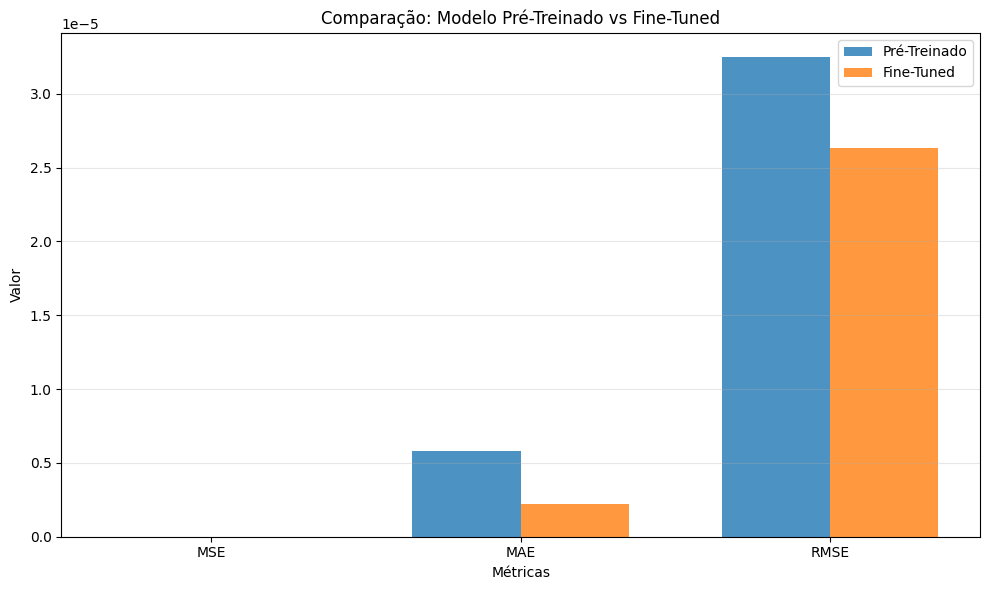


✓ Treinamento concluído! Verifique ../models para salvar o melhor modelo


In [370]:
# ==================== COMPARAR MODELOS ====================
print("\n" + "="*60)
print("RESUMO COMPARATIVO: Pré-Treinado vs Fine-Tuned")
print("="*60)

comparison = pd.DataFrame({
    'Pré-Treinado': results_pretrained,
    'Fine-Tuned': results_finetuned
})
print(comparison[['Pré-Treinado', 'Fine-Tuned']].head())

# Visualização comparativa
plt.figure(figsize=(10, 6))
metrics_names = ['MSE', 'MAE', 'RMSE']
x = np.arange(len(metrics_names))
width = 0.35

values_pretrained = [results_pretrained[m] for m in metrics_names]
values_finetuned = [results_finetuned[m] for m in metrics_names]

plt.bar(x - width/2, values_pretrained, width, label='Pré-Treinado', alpha=0.8)
plt.bar(x + width/2, values_finetuned, width, label='Fine-Tuned', alpha=0.8)

plt.xlabel('Métricas')
plt.ylabel('Valor')
plt.title('Comparação: Modelo Pré-Treinado vs Fine-Tuned')
plt.xticks(x, metrics_names)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Treinamento concluído! Verifique ../models para salvar o melhor modelo")